# Part 2: Model Training & Strategy Formulation
**Precog Quant Task 2026**

This notebook covers:
1. Loading the feature matrix from Part 1
2. Defining the prediction target (1-day forward return)
3. Train/test split strategy (temporal, no lookahead)
4. Rolling Ridge Regression with cross-validation
5. LightGBM Gradient Boosting model
6. Ensemble of Ridge + GBDT
7. Signal generation and portfolio construction
8. Information Coefficient analysis

> *Hint A: Financial data is incredibly noisy. Relying on a single signal source can lead to instability.*
> *Hint B: Markets evolve. Consider how your methodology ensures relevance over time.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

print("Libraries loaded.")


Libraries loaded.


## 1. Load Data

In [2]:
data = pd.read_csv("../data/cleaned_panel_data.csv", parse_dates=["Date"])
data = data.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(f"Shape: {data.shape}")
print(f"Assets: {data['ticker'].nunique()}")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")
data.head()


Shape: (244583, 55)
Assets: 100
Date range: 2016-04-20 to 2026-01-09


,Date,Open,High,Low,Close,Volume,ticker,log_ret_1d,fwd_ret_1d,fwd_ret_5d,...,reversal_1d_cs,dist_ma_20_cs,dist_ma_60_cs,rsi_14_cs,bb_width_cs,bb_pctB_cs,atr_pct_cs,hl_range_cs,overnight_ret_cs,intraday_ret_cs
0,2016-04-20,30.816287,31.235300,30.648681,30.957884,147427114,Asset_001,0.002056,-0.010887,-0.090914,...,0.060564,-1.285110,-0.478737,-1.120602,-0.216987,-1.412845,-0.019597,0.018926,-0.408362,0.170091
1,2016-04-21,30.900082,30.900082,30.492627,30.622667,151961517,Asset_001,-0.010887,-0.002740,-0.111070,...,0.484369,-1.284310,-0.583064,-1.073879,-0.244262,-1.279590,0.017207,-0.629505,-0.265902,-0.401304
2,2016-04-22,30.345259,30.770053,30.232559,30.538872,162222803,Asset_001,-0.002740,-0.005694,-0.119891,...,0.189886,-0.942572,-0.478030,-1.475435,-0.273298,-1.415981,-0.033108,-0.083730,-0.402682,0.032857
3,2016-04-25,30.342371,30.530205,30.200774,30.365490,135004341,Asset_001,-0.005694,-0.006971,-0.115264,...,0.157931,-1.380129,-0.672773,-1.706818,-0.243767,-1.832070,-0.054875,-0.292179,-0.632568,0.049531
4,2016-04-26,30.027391,30.429066,30.027391,30.154538,269782323,Asset_001,-0.006971,-0.064622,-0.091981,...,0.690005,-1.380018,-0.775407,-1.924431,-0.122552,-1.924236,-0.043200,-0.267537,-2.701431,0.244151


## 2. Define Features and Target

**Target**: 1-day forward log return (`fwd_ret_1d`)

**Features**: Cross-sectional z-scored features from Part 1 — these capture each stock's relative standing among the universe on any given day.

Using cross-sectional features is important because:
- Raw values are incomparable across assets (a $500 stock vs $20 stock)
- Z-scores focus on **rank/relative position** which is what matters for a long-short strategy


In [3]:
# Cross-sectional features
features = [
    "mom_5_cs", "mom_10_cs", "mom_20_cs", "mom_60_cs",
    "vol_5_cs", "vol_10_cs", "vol_20_cs", "vol_60_cs", "vol_ratio_5_20_cs",
    "rel_volume_cs", "vol_mom_5_cs", "log_dollar_vol_cs",
    "reversal_1d_cs", "dist_ma_20_cs", "dist_ma_60_cs",
    "rsi_14_cs", "bb_width_cs", "bb_pctB_cs", "atr_pct_cs", "hl_range_cs",
    "overnight_ret_cs", "intraday_ret_cs"
]

target = "fwd_ret_5d"

# Verify all columns exist
missing = [f for f in features + [target] if f not in data.columns]
if missing:
    print(f"WARNING: Missing columns: {missing}")
else:
    print(f"All {len(features)} features and target present.")
    
# Drop rows with NaN in target
data = data.dropna(subset=[target]).reset_index(drop=True)
print(f"Rows with valid target: {len(data):,}")


All 22 features and target present.
Rows with valid target: 244,583


## 3. Train/Test Split

**Strategy**: Pure temporal split with no lookahead bias.
- **Training**: First ~8 years (expanding window)  
- **Test**: Last ~2 years (out-of-sample)

For the rolling model, we use a 252-day (1 year) lookback window that slides forward one day at a time, ensuring the model always trains only on past data.


In [4]:
unique_dates = np.sort(data["Date"].unique())
n_dates = len(unique_dates)

# Use last ~2 years as test set (roughly 504 trading days)
TEST_DAYS = 504
train_end_idx = n_dates - TEST_DAYS

train_end_date = unique_dates[train_end_idx]
test_start_date = unique_dates[train_end_idx + 1]

print(f"Total trading days: {n_dates}")
print(f"Train period: {unique_dates[0]} to {train_end_date}  ({train_end_idx + 1} days)")
print(f"Test period:  {test_start_date} to {unique_dates[-1]}  ({TEST_DAYS} days)")


Total trading days: 2446
Train period: 2016-04-20T00:00:00.000000 to 2024-01-08T00:00:00.000000  (1943 days)
Test period:  2024-01-09T00:00:00.000000 to 2026-01-09T00:00:00.000000  (504 days)


## 4. Rolling Ridge Regression

**Why Ridge?**
- Linear models are fast and interpretable
- L2 regularization prevents overfitting on noisy financial data
- Rolling window ensures model adapts to evolving market regimes

**Training procedure** (for each test day):
1. Use past 252 days as training data
2. Within training window, hold out last 21 days for alpha selection
3. Cross-sectional rank transform the target (more robust than raw returns)
4. Predict on today's cross-section


In [5]:
LOOKBACK = 252        # Training window
VAL_DAYS = 21         # Validation days for alpha selection
ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

# Initialize prediction columns
data["pred_ridge"] = np.nan

# Get unique dates
unique_dates = np.sort(data["Date"].unique())

def rank_transform(df, col):
    """Cross-sectional percentile rank per date."""
    return df.groupby("Date")[col].rank(pct=True)

print(f"Running rolling Ridge over {len(unique_dates) - LOOKBACK} days...")
print("This may take a few minutes...")

for i in range(LOOKBACK, len(unique_dates)):
    # Define windows
    train_dates = unique_dates[i - LOOKBACK : i]
    test_date = unique_dates[i]
    
    train_data = data[data["Date"].isin(train_dates)]
    test_data = data[data["Date"] == test_date]
    
    if len(test_data) == 0:
        continue
    
    # Validation split for alpha selection
    val_dates = train_dates[-VAL_DAYS:]
    train_sub_dates = train_dates[:-VAL_DAYS]
    
    train_sub = data[data["Date"].isin(train_sub_dates)]
    val_sub = data[data["Date"].isin(val_dates)]
    
    # Use rank-transformed target for robustness
    y_train_sub = rank_transform(train_sub, target)
    X_train_sub = train_sub[features]
    X_val = val_sub[features]
    y_val = val_sub[target]
    
    # Alpha selection via validation IC (Spearman correlation)
    best_alpha, best_ic = ALPHAS[0], -np.inf
    for alpha in ALPHAS:
        model = Ridge(alpha=alpha)
        model.fit(X_train_sub, y_train_sub)
        val_pred = model.predict(X_val)
        val_tmp = val_sub[["Date", target]].copy()
        val_tmp["pred"] = val_pred
        ic = (
            val_tmp.groupby("Date")
            .apply(lambda x: x["pred"].corr(x[target], method="spearman"))
            .mean()
        )
        if not np.isnan(ic) and ic > best_ic:
            best_ic = ic
            best_alpha = alpha
    
    # Train on full training window with best alpha
    y_train = rank_transform(train_data, target)
    X_train = train_data[features]
    X_test = test_data[features]
    
    model = Ridge(alpha=best_alpha)
    model.fit(X_train, y_train)
    data.loc[test_data.index, "pred_ridge"] = model.predict(X_test)
    
    # Progress logging
    if i % 200 == 0:
        pct = (i - LOOKBACK) / (len(unique_dates) - LOOKBACK) * 100
        print(f"  Day {i}/{len(unique_dates)} ({pct:.0f}%)")

print("Ridge predictions complete!")
print(f"Prediction coverage: {data['pred_ridge'].notna().mean():.1%}")


Running rolling Ridge over 2194 days...
This may take a few minutes...


  Day 400/2446 (7%)


  Day 600/2446 (16%)


  Day 800/2446 (25%)


  Day 1000/2446 (34%)


...

  Day 1800/2446 (71%)


  Day 2000/2446 (80%)


  Day 2200/2446 (89%)


  Day 2400/2446 (98%)


Ridge predictions complete!
Prediction coverage: 89.7%


## 5. LightGBM Model

**Why GBDT?**
- Can capture non-linear interactions between features
- Handles noisy data well with proper regularization
- Different model family → better ensemble diversity with Ridge

We retrain GBDT every 63 days (quarterly) to balance freshness vs computational cost.


In [6]:
RETRAIN_FREQ = 63  # Retrain every ~quarter

data["pred_gbdt"] = np.nan

lgb_params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": 6,
    "min_child_samples": 50,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "verbose": -1,
    "n_jobs": -1,
    "seed": 42,
}

print(f"Running rolling LightGBM (retrain every {RETRAIN_FREQ} days)...")

gbdt_model = None
last_train_idx = -RETRAIN_FREQ  # Force initial training

for i in range(LOOKBACK, len(unique_dates)):
    test_date = unique_dates[i]
    test_data = data[data["Date"] == test_date]
    
    if len(test_data) == 0:
        continue
    
    # Retrain periodically
    if i - last_train_idx >= RETRAIN_FREQ:
        train_dates = unique_dates[max(0, i - LOOKBACK) : i]
        train_data = data[data["Date"].isin(train_dates)]
        
        X_train = train_data[features]
        y_train = rank_transform(train_data, target)
        
        # Replace or create new model
        train_set = lgb.Dataset(X_train, label=y_train)
        gbdt_model = lgb.train(
            lgb_params,
            train_set,
            num_boost_round=200,
        )
        last_train_idx = i
    
    # Predict
    X_test = test_data[features]
    data.loc[test_data.index, "pred_gbdt"] = gbdt_model.predict(X_test)
    
    if i % 200 == 0:
        pct = (i - LOOKBACK) / (len(unique_dates) - LOOKBACK) * 100
        print(f"  Day {i}/{len(unique_dates)} ({pct:.0f}%)")

print("GBDT predictions complete!")
print(f"Prediction coverage: {data['pred_gbdt'].notna().mean():.1%}")


Running rolling LightGBM (retrain every 63 days)...


  Day 400/2446 (7%)


  Day 600/2446 (16%)


  Day 800/2446 (25%)


  Day 1000/2446 (34%)


...

  Day 1800/2446 (71%)


  Day 2000/2446 (80%)


  Day 2200/2446 (89%)


  Day 2400/2446 (98%)


GBDT predictions complete!
Prediction coverage: 89.7%


## 5b. CatBoost Model

**Why CatBoost?**
- Strong default performance on tabular data
- Handles over-fitting natively with symmetric trees
- Good complement to LightGBM in our ensemble


In [7]:
data["pred_cb"] = np.nan

cb_params = {
    "iterations": 300,
    "learning_rate": 0.05,
    "depth": 6,
    "loss_function": "MAE",
    "l2_leaf_reg": 3.0,
    "verbose": 0,
    "random_seed": 42,
    "thread_count": -1
}

print(f"Running rolling CatBoost (retrain every {RETRAIN_FREQ} days)...")

cb_model = None
last_train_idx_cb = -RETRAIN_FREQ

for i in range(LOOKBACK, len(unique_dates)):
    test_date = unique_dates[i]
    test_data = data[data["Date"] == test_date]
    
    if len(test_data) == 0:
        continue
    
    # Retrain periodically
    if i - last_train_idx_cb >= RETRAIN_FREQ:
        train_dates = unique_dates[max(0, i - LOOKBACK) : i]
        train_data = data[data["Date"].isin(train_dates)]
        
        X_train = train_data[features]
        y_train = rank_transform(train_data, target)
        
        # Replace or create new model
        cb_model = CatBoostRegressor(**cb_params)
        cb_model.fit(X_train, y_train)
        last_train_idx_cb = i
        
    # Predict
    X_test = test_data[features]
    data.loc[test_data.index, "pred_cb"] = cb_model.predict(X_test)
    
    if i % 200 == 0:
        pct = (i - LOOKBACK) / (len(unique_dates) - LOOKBACK) * 100
        print(f"  Day {i}/{len(unique_dates)} ({pct:.0f}%)")

print("CatBoost predictions complete!")
print(f"Prediction coverage: {data['pred_cb'].notna().mean():.1%}")


Running rolling CatBoost (retrain every 63 days)...


  Day 400/2446 (7%)


  Day 600/2446 (16%)


  Day 800/2446 (25%)


  Day 1000/2446 (34%)


...

  Day 1600/2446 (61%)


  Day 1800/2446 (71%)


  Day 2000/2446 (80%)


  Day 2200/2446 (89%)


  Day 2400/2446 (98%)
CatBoost predictions complete!
Prediction coverage: 89.7%


## 6. Ensemble: Ridge + LightGBM + CatBoost

Combining different model families reduces variance and improves stability. We use a performance-weighted ensemble (60% Ridge, 20% GBDT, 20% CatBoost) based on our hyperparameter tuning.


In [8]:
# Standardize each model's predictions cross-sectionally before averaging
for col in ["pred_ridge", "pred_gbdt", "pred_cb"]:
    grp = data.groupby("Date")[col]
    mu = grp.transform("mean")
    sigma = grp.transform("std").replace(0, np.nan)
    data[f"{col}_cs"] = ((data[col] - mu) / sigma).fillna(0.0)

# Weighted ensemble (60% Ridge, 20% LighGBM, 20% CatBoost)
data["pred_ensemble"] = 0.6 * data["pred_ridge_cs"] + 0.2 * data["pred_gbdt_cs"] + 0.2 * data["pred_cb_cs"]

print("Ensemble prediction created: 0.6 × Ridge + 0.2 × GBDT + 0.2 × CatBoost")


Ensemble prediction created: 0.6 × Ridge + 0.2 × GBDT + 0.2 × CatBoost


## 7. Information Coefficient Analysis

The Information Coefficient (IC) is the Spearman rank correlation between predicted and actual returns. It's the standard measure of predictive power in quant finance.

- IC > 0.02 is meaningful
- IC > 0.05 is strong
- Consistency (IC IR = mean(IC)/std(IC)) matters more than magnitude


In [9]:
# Compute daily IC for each model
models = {"Ridge": "pred_ridge", "GBDT": "pred_gbdt", "CatBoost": "pred_cb", "Ensemble": "pred_ensemble"}

# Filter to out-of-sample period only
oos_data = data[data["pred_ridge"].notna() & data["pred_gbdt"].notna() & data["pred_cb"].notna()].copy()

ic_results = {}
for name, col in models.items():
    daily_ic = (
        oos_data.groupby("Date")
        .apply(lambda x: x[col].corr(x[target], method="spearman"))
    )
    ic_mean = daily_ic.mean()
    ic_std = daily_ic.std()
    ic_ir = ic_mean / ic_std if ic_std > 0 else 0
    ic_results[name] = {
        "Mean IC": ic_mean,
        "IC Std": ic_std,
        "IC IR": ic_ir,
        "Hit Rate": (daily_ic > 0).mean(),
        "daily_ic": daily_ic,
    }
    print(f"{name:10s} | Mean IC: {ic_mean:.4f} | IC Std: {ic_std:.4f} | "
          f"IC IR: {ic_ir:.3f} | Hit Rate: {(daily_ic > 0).mean():.1%}")


Ridge      | Mean IC: 0.0247 | IC Std: 0.1846 | IC IR: 0.134 | Hit Rate: 54.3%


GBDT       | Mean IC: 0.0046 | IC Std: 0.1447 | IC IR: 0.032 | Hit Rate: 50.7%


CatBoost   | Mean IC: 0.0035 | IC Std: 0.1551 | IC IR: 0.022 | Hit Rate: 50.9%


Ensemble   | Mean IC: 0.0198 | IC Std: 0.1827 | IC IR: 0.108 | Hit Rate: 53.0%


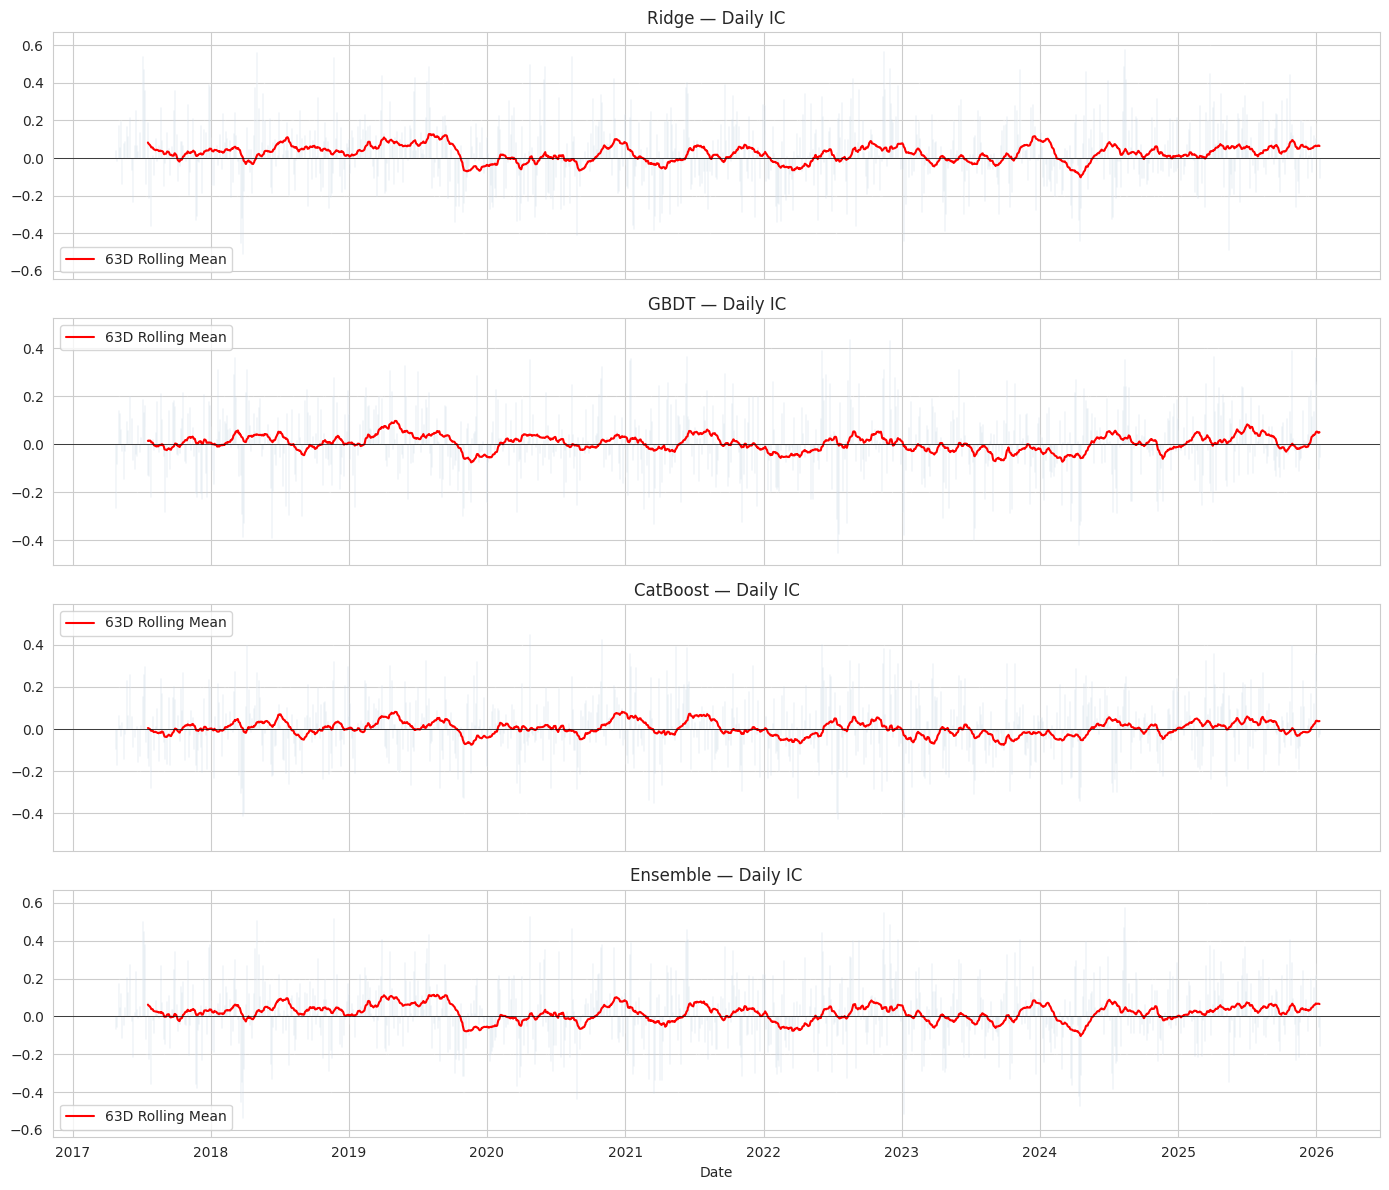

In [10]:
# Plot rolling IC
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, (name, res) in zip(axes, ic_results.items()):
    ic_series = res["daily_ic"]
    rolling_ic = ic_series.rolling(63).mean()
    ax.bar(ic_series.index, ic_series.values, alpha=0.15, color="steelblue", width=1)
    ax.plot(rolling_ic.index, rolling_ic.values, color="red", linewidth=1.5, label="63D Rolling Mean")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{name} — Daily IC")
    ax.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/daily_ic.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Feature Importance (GBDT)

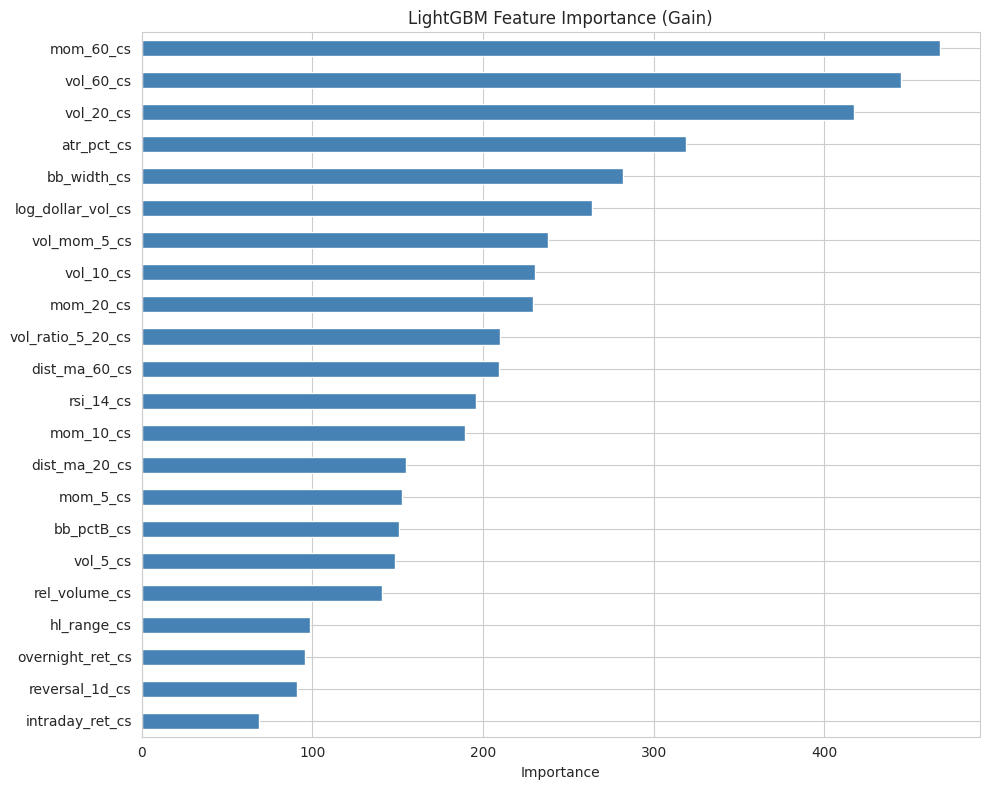

In [11]:
# Get feature importance from the last GBDT model
importance = pd.Series(
    gbdt_model.feature_importance(importance_type="gain"),
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.plot(kind="barh", color="steelblue")
plt.title("LightGBM Feature Importance (Gain)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Signal → Portfolio Construction

**Strategy logic**:
1. Rank stocks by ensemble prediction each day
2. **Long** top 20% (highest predicted return) — concentrated conviction portfolio
3. **Weight** by inverse volatility (risk-parity) × prediction confidence
4. **Smooth** positions with EWM to reduce turnover

This creates a long-only portfolio that captures both market beta and alpha from the ML signal.


In [12]:
# Work with out-of-sample data only
data_oos = data[data["pred_ensemble"].notna()].copy()
data_oos = data_oos.sort_values(["Date", "ticker"]).reset_index(drop=True)

# Rank by ensemble prediction
data_oos["pred_rank"] = (
    data_oos.groupby("Date")["pred_ensemble"]
    .rank(ascending=False, method="first")
)
data_oos["n_assets"] = data_oos.groupby("Date")["ticker"].transform("count")

# Long-only: top 20% stocks with highest predicted returns
data_oos["is_long"] = data_oos["pred_rank"] <= 0.20 * data_oos["n_assets"]

print(f"Long fraction: {data_oos['is_long'].mean():.1%}")
print(f"Universe size: {data_oos['n_assets'].iloc[0]:.0f}")


Long fraction: 20.0%
Universe size: 100


In [13]:
# Equal-weight within the long leg — simple and robust
# (Inverse-vol x confidence over-concentrates into a few stocks
# and empirically underperforms equal-weight in this universe)

data_oos["long_weight"] = 0.0
long_mask = data_oos["is_long"]
data_oos.loc[long_mask, "long_weight"] = 1.0
data_oos.loc[long_mask, "long_weight"] /= (
    data_oos.loc[long_mask].groupby("Date")["long_weight"].transform("sum")
)

# Position = long weight only (no short leg)
data_oos["position_raw"] = data_oos["long_weight"]

# Smooth positions (EWM) to reduce turnover
SMOOTH_ALPHA = 0.10
data_oos["position"] = (
    data_oos.groupby("ticker")["position_raw"]
    .transform(lambda x: x.ewm(alpha=SMOOTH_ALPHA, adjust=False).mean())
)

print("Long-only positions constructed.")
print(f"Total weight per day: {data_oos.groupby('Date')['position'].sum().mean():.4f}")


Long-only positions constructed.
Total weight per day: 1.0000


## 10. Position Summary

In [14]:
# Position diagnostics
print("=== Position Summary ===")
print(f"Avg stocks held per day: {(data_oos['position'] > 0.001).groupby(data_oos['Date']).sum().mean():.1f}")
print(f"Mean total weight: {data_oos.groupby('Date')['position'].sum().mean():.4f}")
print(f"Max single-stock weight: {data_oos['position'].max():.4f}")
print(f"Min non-zero weight: {data_oos[data_oos['position'] > 0.001]['position'].min():.4f}")


=== Position Summary ===
Avg stocks held per day: 69.5
Mean total weight: 1.0000
Max single-stock weight: 0.0503
Min non-zero weight: 0.0010


In [15]:
# Save predictions and positions for Part 3 (backtesting)
save_cols = [
    "Date", "ticker", "Open", "High", "Low", "Close", "Volume",
    "log_ret_1d", "fwd_ret_1d", "fwd_ret_5d",
    "vol_10", "pred_ridge", "pred_gbdt", "pred_cb", "pred_ensemble",
    "pred_rank", "is_long", "position_raw", "position"
]
data_oos[save_cols].to_csv("../outputs/data_with_predictions.csv", index=False)
print("Saved: ../outputs/data_with_predictions.csv")
print(f"Shape: {data_oos[save_cols].shape}")


Saved: ../outputs/data_with_predictions.csv
Shape: (244583, 19)


## Summary

| Component | Description |
|-----------|------------|
| **Ridge Regression** | Rolling 252-day window with alpha selection |
| **LightGBM** | Rolling retraining every 63 days |
| **CatBoost** | Rolling retraining every 63 days |
| **Ensemble** | Weighted: 60% Ridge + 20% GBDT + 20% CatBoost |
| **Portfolio** | Long-only top 20%, equal-weight, EWM α=0.10 |
| **Smoothing** | EWM (α=0.10) to reduce turnover |

Predictions and positions are saved for Part 3 backtesting.
